<a href="https://colab.research.google.com/github/it-ces/PUBLIC-AI/blob/main/DIAI/Anova_sales_mba(ai_page).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Iván Andrés Trujillo Abella
# ivantrujillo1229@gmail.com

## A firm sells fragrances in different malls. We registred the quanity sells in one year in each mall, we need identify if the place could matter in the number of sells.


In [26]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns

In [27]:
url = 'https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/sales_in_malls_mba.csv'

In [28]:
df  = pd.read_csv(url)

In [29]:
df.columns

Index(['mall', 'quantities'], dtype='object')

In [30]:
df['mall'].value_counts()

,count
mall,
mall A,365
mall B,365
mall C,365


In [31]:
df.groupby(by=['mall']).describe()

quantities                                                              \
            count        mean         std         min         25%         50%   
mall                                                                            
mall A      365.0  450.251120   90.985050  199.965311  390.626550  448.077170   
mall B      365.0  543.834742  100.332295  247.074802  478.516494  541.973632   
mall C      365.0  465.780139  100.249470  168.559190  395.754772  464.615815   

                                
               75%         max  
mall                            
mall A  513.021618  669.941799  
mall B  608.180004  857.982693  
mall C  536.974504  734.150892

<Axes: xlabel='mall', ylabel='quantities'>

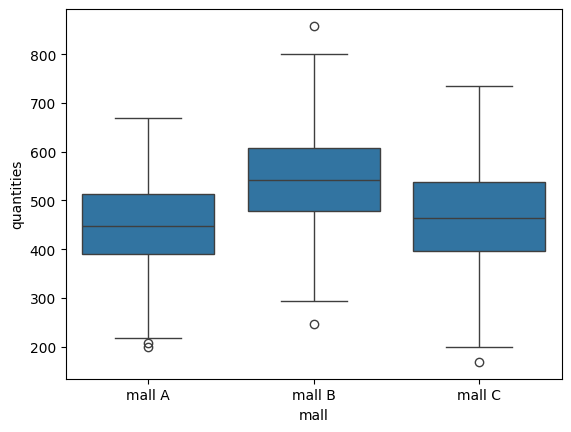

In [32]:
sns.boxplot(data=df, x='mall', y='quantities')

# The anova hypotheses are:

\begin{equation}
H0: \text{todas las medias (poblacionales) son iguales} \\
H1: \text{AL MENOS UNA de las medias (poblacionales) ES DIFERENTE}
\end{equation}


que vamos  a decir si POR EJEMPLO LLÉGASE A PASAR QUE EL VALOR DE P < 0.05 vamos a decir H1, es decir al menos una de las media es diferente.
si P>= 0,05 decimos no hay diferencias entre las medias poblacionales (H0).

In [33]:
mallA = df[df['mall']=='mall A']['quantities']
mallB = df[df['mall']=='mall B']['quantities']
mallC = df[df['mall']=='mall C']['quantities']

In [34]:
scipy.stats.f_oneway(mallA, mallB, mallC).pvalue  # caluc aNOVA
#at leas one of them is different!

np.float64(1.6791886807012438e-39)

In [36]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Test de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['quantities'],   # variable respuesta
    groups=df['mall'],        # grupos
    alpha=0.05
)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper   reject
-----------------------------------------------------
mall A mall B  93.5836    0.0 76.6822  110.485   True
mall A mall C   15.529 0.0793 -1.3724  32.4304  False
mall B mall C -78.0546    0.0 -94.956 -61.1532   True
-----------------------------------------------------


 el centro comercial B presenta un nivel de ventas significativamente superior respecto a A y C, mientras que no se evidencian diferencias estadísticas entre A y C.